Cross-Country Solar Data Comparison

Objective
Synthesize the cleaned datasets from Benin, Sierra Leone, and Togo to identify relative solar potential and key differences across countries.

In [1]:
from pathlib import Path
import os

p = Path.cwd()
while not (p / "data").exists():
    p = p.parent
os.chdir(p)

print("Working directory set to:", os.getcwd())


Working directory set to: C:\KAIM Week-0\solar-challenge-week1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

# Load Cleaned Data
benin = pd.read_csv('data/benin_clean.csv', parse_dates=['Timestamp'])
sierra = pd.read_csv('data/sierra_leone_clean.csv', parse_dates=['Timestamp'])
togo = pd.read_csv('data/togo_clean.csv', parse_dates=['Timestamp'])

benin['Country'] = 'Benin'
sierra['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

df_all = pd.concat([benin, sierra, togo], ignore_index=True)
df_all.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,TModB,Comments,GHI_z,DNI_z,DHI_z,ModA_z,ModB_z,WS_z,WSgust_z,Country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,...,26.2,NaN,-0.730101,-0.639590,-0.733872,-0.723748,-0.723087,-1.322830,-1.187310,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,...,26.2,NaN,-0.729799,-0.639590,-0.733872,-0.723748,-0.723087,-1.322830,-1.384440,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,...,26.2,NaN,-0.729799,-0.639590,-0.733872,-0.723748,-0.723087,-1.135735,-0.842333,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,...,26.3,NaN,-0.729799,-0.639208,-0.733242,-0.723748,-0.723087,-1.198100,-1.039463,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,...,26.3,NaN,-0.729497,-0.639208,-0.733242,-0.723748,-0.723087,-1.260465,-1.039463,Benin


C:\Users\samha\AppData\Local\Temp\ipykernel_8460\361488550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette='viridis')


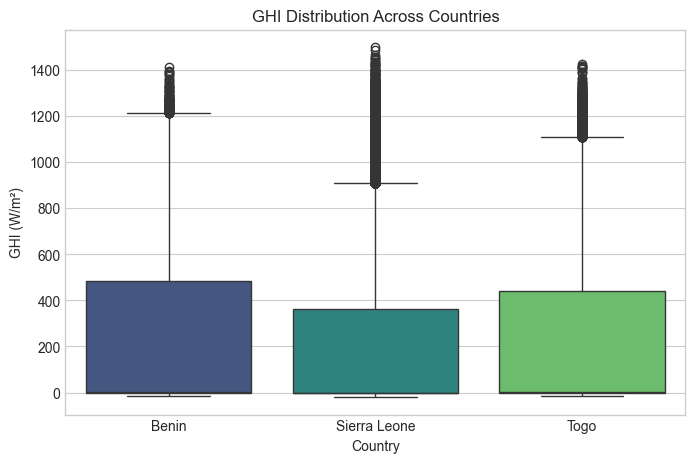

C:\Users\samha\AppData\Local\Temp\ipykernel_8460\361488550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette='viridis')


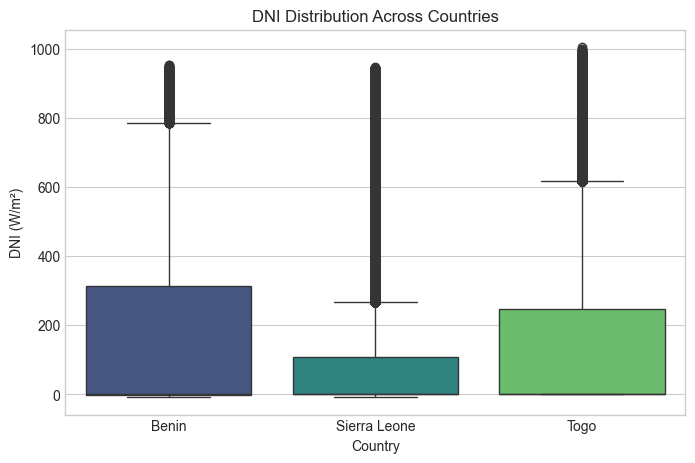

C:\Users\samha\AppData\Local\Temp\ipykernel_8460\361488550.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette='viridis')


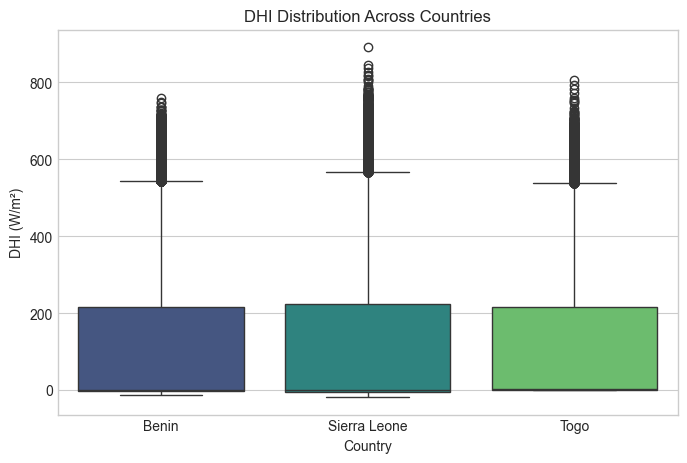

In [3]:
metrics = ['GHI', 'DNI', 'DHI']
for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Country', y=metric, data=df_all, palette='viridis')
    plt.title(f'{metric} Distribution Across Countries')
    plt.ylabel(f'{metric} (W/m²)')
    plt.xlabel('Country')
    plt.show()

In [4]:
summary = (
    df_all.groupby('Country')[['GHI', 'DNI', 'DHI']]
    .agg(['mean', 'median', 'std'])
    .round(2)
)
summary

GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         240.56    1.8  331.13  167.19   -0.1  261.71  115.36    1.6   
Sierra Leone  201.96    0.3  298.50  116.38   -0.1  218.65  113.72   -0.1   
Togo          230.56    2.1  322.53  151.26    0.0  250.96  116.44    2.5   

                      
                 std  
Country               
Benin         158.69  
Sierra Leone  158.95  
Togo          156.52

In [5]:
# Statistical Testing – ANOVA or Kruskal–Wallis
for country, data in df_all.groupby('Country'):
    stat, p = stats.shapiro(data['GHI'].sample(min(5000, len(data))))
    print(f'{country} Shapiro test p-value: {p:.4f}')

ghi_groups = [benin['GHI'].dropna(), sierra['GHI'].dropna(), togo['GHI'].dropna()]
stat, p = stats.kruskal(*ghi_groups)
print(f'Kruskal–Wallis test statistic: {stat:.3f}, p-value: {p:.4f}')
if p < 0.05:
    print('→ Significant differences detected between countries’ GHI distributions.')
else:
    print('→ No statistically significant difference in GHI among countries.')

Benin Shapiro test p-value: 0.0000
Sierra Leone Shapiro test p-value: 0.0000
Togo Shapiro test p-value: 0.0000
Kruskal–Wallis test statistic: 4524.883, p-value: 0.0000
→ Significant differences detected between countries’ GHI distributions.


C:\Users\samha\AppData\Local\Temp\ipykernel_8460\3390787068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_ghi.index, y=avg_ghi.values, palette='coolwarm')


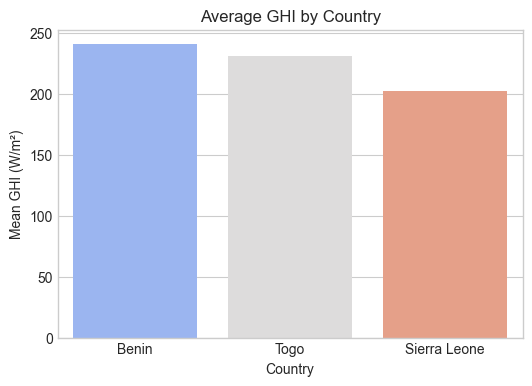

Country
Benin           240.559452
Togo            230.555040
Sierra Leone    201.957515
Name: GHI, dtype: float64

In [6]:
avg_ghi = df_all.groupby('Country')['GHI'].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
sns.barplot(x=avg_ghi.index, y=avg_ghi.values, palette='coolwarm')
plt.title('Average GHI by Country')
plt.ylabel('Mean GHI (W/m²)')
plt.xlabel('Country')
plt.show()
avg_ghi

Key Observations
- Benin shows the highest average and median GHI, indicating the strongest solar potential overall.
- Togo follows closely but shows higher variability, suggesting localized weather fluctuations or data noise.
- Sierra Leone presents lower GHI and higher humidity, which could affect module efficiency and maintenance cycles.

Solar potential ranking:
1. Benin (Malanville)
2. Togo (Dapaong)
3. Sierra Leone (Bumbuna)
